# Técnicas avanzadas de diseño de software

## Ray, Dask y Spark

<img src="images/cover.png" width=512 heigth=341/>


### Diego, Franco y Francisco

<img src="images/Apache_Spark_logo.svg.png"/>

### Contexto e historia

<img src="images/hadoop-logo.jpg" width=281 heigth=71/>

* Antes de 2010, se usaba Apache Hadoop para cómputo distribuido a gran escala.
* Usaba el HDFS (Hadoop Distributed File System) y MapReduce para llevar la query a los datos.
* Requeria leer y escribir los datos en disco cada vez, por lo que sufria la latencia I/O.

<img src="images/mapreduce-workflow-768.png" width=384 heigth=251/>


### Contexto e historia

* En 2010 sale el paper introductorio de Spark: Matei Zaharia, Mosharaf Chowdhury, Michael J Franklin, Scott Shenker, Ion Stoica (University of California, Berkeley)
* Spark mejora hasta 10 veces el desempeño de Hadoop al usar la memoria principal y el caché para resultados intermedios.
* Sigue soportando el HDFS!

<img src="images/spark-paper.png" width=986 heigth=319/>

### Spark

* Parte del proyecto Apache.
* Se construye sobre Scala y require Java (8, 11 o 17).
* Además de Scala y Java, corre en Python y R (y en shell).
* En particular se puede usar el modulo PySpark para paralelizar un script con una sintaxis "amigable".
* También se pueden usar operaciones SQL o conectar a base de datos SQL.

<img src="images/Apache_Spark_logo.svg.png" width=384 heigth=200/>

### Estructura y abstracciones

* Abstracción principal: RDD (Resilient Distributed Dataset). Los RDD son:
    * Inmutables
    * Lazy
    * Resistentes a fallas
    * Paralelizables en memoria
    * Sin esquema!
    * Objetos de la JVM

<img src="images/spark-rdd.png" width=545 heigth=342/>

### Estructura y abstracciones

* Hoy se usa la abstraccion mas moderna del Dataset, que sí tiene esquema, además de multiples optimizaciones.
* No obstante, para Python sólo está disponible el DataFrame (también con esquema), consistente con Pandas y útil para interactividad.
* El Dataset/DataFrame admite operaciones relacionales; se trata como una tabla de SQL.

<img src="images/rdd-img-1.png" width=512 heigth=298/>

In [ ]:
from pyspark.sql import SparkSession

# Step 1: Create a Spark session
spark = SparkSession.builder.appName("SimpleSparkApp").getOrCreate()

# Step 2: Create a simple DataFrame
data = [(1, "John Doe", 29), (2, "Jane Smith", 35), (3, "Sam Brown", 22)]
columns = ["id", "name", "age"]

# Convert the list of Row objects to a DataFrame
df = spark.createDataFrame(data,schema=columns)

df.show()

df_25 = df.filter(df['age'] > 30)

print("Over 30 y/o:")
df_25.show()

# stop the spark application
spark.stop()

### Estructura y abstracciones

* Cualquiera de estas estructuras admite 2 tipos de operaciones:
    * Transformaciones (RDD => RDD)
    * Acciones (RDD => Output)
* Son las operaciones análogas a Map y Reduce.
* Map es Lazy: no se computa hasta encontrar un reduce que requiera el resultado.
* También suele separarse entre Transformaciones "Narrow" y "Wide" dependiendo de si requieren "Shuffling".
* El Shuffling es costoso; operaciones como "reduceByKey" y "join" deben usarse con cuidado.

<img src="images/function_types.webp" width=363 heigth=222/>

In [7]:
from pyspark import SparkContext, SparkConf

conf = SparkConf().setAppName("PyCount").setMaster("local")
sc = SparkContext(conf=conf)

lines = sc.textFile("data/example_text.txt") ## Solo puntero al archivo
lineLengths = lines.map(lambda s: len(s)) ## Lazy
totalLength = lineLengths.reduce(lambda a, b: a + b) ## Aca se ejecuta todo el programa
print(totalLength)

sc.stop()

### Ciclo de vida y persistencia

* Internamente, Spark debe construir un Grafo Direccionado Acíclico (DAG) con "stages" de ejecución.
* Dentro de cada stage hay múltiples tareas (Tasks), cada una con una partición del RDD y una transformación a cargo. Esto lo organiza el **DAG Scheduler**.
* Luego el **Task Scheduler** separa las tareas en distintos nodos (Workers) a través del **Cluster Manager** (Mesos, Yarn, etc.) para ser ejecutadas en paralelo. El Task Scheduler NO sabe nada de stages.
* Cada nodo recibe un proceso ejecutor (Executor) para completar tareas. Pero este ejecutor además puede usar múltiples cores!
* Cuando hay un shuffle (o el reduce final), debe reorganizarse el cluster; el nodo "driver" se ocupa de esto.
* Además se puede usar explícitamente "cache()" o "persist()" - pero esto también sirve para agilizar el cómputo.

<img src="images/dag_complete.png" width=432 heigth=258/>

In [ ]:
from typing import Iterable, List
import numpy as np
from pyspark.sql import SparkSession
from pyspark import SparkConf

D = 10  # Number of dimensions

def readPointBatch(iterator: Iterable[str]) -> List[np.ndarray]:
    # Extract points from file

def gradient(matrix: np.ndarray, w: np.ndarray) -> np.ndarray:
    # Compute logistic regression gradient

conf = SparkConf().setAppName("PythonLR").setMaster("local[4]")
spark = SparkSession.builder.config(conf=conf).getOrCreate()

points = spark.read.text("lr_data.csv").rdd.map(lambda r: r[0]).mapPartitions(readPointBatch).cache()
iterations = 100

# Initialize w to a random value
w = 2 * np.random.ranf(size=D) - 1
print("Initial w: " + str(w))

for i in range(iterations):
    print("On iteration %i" % (i + 1))
    w -= points.map(lambda m: gradient(m, w)).reduce(np.add)

print("Final w: " + str(w))

spark.stop()

### Paralelización y eficiencia

* El el programa anterior, cada iteración es un stage.
* En una PC "decente" (Ryzen 7) el tiempo de ejecución en 1 núcleo es aprox. 1 seg por stage.
* El cache mejora este numero visiblemente, aunque no por mucho.
* Llamativamente, el tiempo de CPU reportado por "time" es MENOR incluso que el de 1 stage.
* No obstante, agregar más cores no divide sino que MULTIPLICA el tiempo de cómputo.

<img src="images/ui_jobs.png" width=614 heigth=405/>

### Paralelización y eficiencia

* Usar más cores no implica menor tiempo! El overhead del Task Scheduler y la reducción de variables en múltiples nodos (la clausura) puede ser mayor.
* Para disminuir el tiempo real de ejecución, el sistema debe tener pocos recursos o el problema debe ser muy complejo.
* Similarmente, usar cache podría no ahorrar el mismo tiempo que años atrás.
* Detalles sobre las tareas, stages, y recursos utilizados pueden verse mejor en el Spark UI, por defecto funcionando en tiempo real en el puerto 4040 hasta que termina la sesión.

<img src="images/ui_jobs.png" width=614 heigth=405/>

### Variables compartidas y memoria

* No obstante, Spark incluye optimizaciones para reducir el overhead lo más posible. Por ejemplo, 2 tipos de variables compartidas:
    * Broadcast: de solo lectura guardada en caché; evita enviar una copia a cada nodo. Spark hace esto por defecto dentro de cada stage (pero no entre 2 stages).
    * Accumulator: se "suman" con alguna operación asociativa y conmutativa tal que se puede separar en distintas particiones para ser reducida al final. Se usa por defecto en varias funciones; puede ser personalizada con un valor base y una regla de adición.
* Además, usando "persist()" en lugar de "cache()" se puede especificar si usar RAM (default), disco, o un conjunto de reglas para decidir.

<img src="images/sparkcontext-broadcast-executors.png" width=460 heigth=284/>

### Otras librerías: MLlib

* Se usa sobre DataFrames (soporte para RDDs deprecado). En Python se llama a *pyspark.ml*.
* Cubre estadísticas básicas, correlaciones, pruebas de hipótesis.
* También Feature Extraction (TF-IDF, Word2Vec, CountVectorizer), Transformers (Tokenizer, Scalers, Normalizer), Clasificación (Regresión Logística, Random Forest, Gradiente), Clustering (K-Means) y más.
* Admite leer otros tipos de datos, como LibSVM imágenes!
* Admite Pipelines!
* El algoritmo de antes pasa a demorar solo segundos, en especial si los datos no son exigentes (se consigue convergencia rápidamente).

<img src="images/spark-mllib.png" width=550 heigth=261/>

In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.classification import LogisticRegression

spark = SparkSession.builder.appName("LogisticRegressionWithElasticNet").getOrCreate()

iterations = 100

# Load training data
training = spark.read.format("libsvm").load("lr_data_libsvm.txt")

lr = LogisticRegression(maxIter=iterations, regParam=0.3)

# Fit the model
lrModel = lr.fit(training)

# Print the coefficients and intercept for logistic regression
print("Coefficients: " + str(lrModel.coefficients))
print("Intercept: " + str(lrModel.intercept))

spark.stop()

### Otras librerías: Streaming

* Anteriormente se usaba un *StreamingContext* junto con una abstracción llamada DStream (Discretized Stream), que internamente es una colección de RDDs. No obstante, esta implementación está discontinuada.
* Hoy se usan DataFrames con un modelo de programación más general llamado "Structured Streaming"; simplemente, la tabla que se require remotamente se va reconstruyendo línea a línea.
* Se lee incrementalmente la menor cantidad necesaria de datos, luego se descartan.
* La tabla resultante (luego de una operación) se va actualizando automáticamente cuando se detectan cambios remotos.

<img src="images/streaming.png" width=491 heigth=264/>

### Comparativa con otras herramientas - Dask

* Existen papers publicados haciendo esta comparativa ("Performance comparison of Dask and Apache Spark on HPC systems for Neuroimaging", Mathieu Dugré & Valérie Hayot-Sasson 2024 - https://arxiv.org/html/2406.01409v1).
* No obstante, estas implementaciones tienen que ver con cómputo científico de gran volumen de datos (en el paper citado, 606 GiB).
* En general, se entiende que Spark empieza a convenir a muy gran escala (incluso con 606 GiB parece que no!), pero pierde la competencia a escalas bajas-medias (en 1 máquina).
* Desde Dask hicieron pruebas con el TPC-H benchmark.

<img src="images/spark-vs-dask.png" width=729 heigth=270/>

### Comparativa con otras herramientas - Ray

* Hay menos comparativas directas; se entiende que se usan para distintas cosas.
* En teoría, Ray estaría mejor optimizado para tareas específicas, en especial de entrenamiento en el ámbito de ML, a pesar de que es más "multipropósito" que Dask.
* Para grandes volumenes de datos con estructuras fuera de una tabla SQL, Ray ganaría incluso en grandes escalas. Por ejemplo, para la clasificación de imágenes!

<img src="images/spark-vs-ray_imgs.png" width=551 heigth=415/>

<img src="images/ray.png" width=800 heigth=800/>


##  Acerca de Ray

* Es un framework de **código abierto** para computación distribuida, del mismo laboratorio que Spark, se instala usando `pip install -U "ray[default]"`.
* Se enfoca principalmente en **escalar** aplicaciones de **Python** y especificamente de **Inteligencia Artificial**.
* Simplifica la computación distribuida mediante **primitivas escalables**, **librerias especializadas para IA** en diferente etapas (preprocesamiento, entrenamiento y afinación de hiper) y un **manejo de recursos unificado**.
* Otras API de Ray: Ray Java y Ray C++.
<img src="images/ray_animal.jpg" width=600 heigth=400/>

### Ray: de funciones a tareas

> Ray permite ejecutar **funciones arbitrarias de forma asíncrona** (***tasks***) en distintos *workers*.


In [6]:
import ray
import numpy as np

# Crea un 'Ray Instance'
context = ray.init()
print(context.dashboard_url)

@ray.remote
def make_array():
    a = np.random.rand(3)
    return a

@ray.remote
def add_arrays(a, b):
    return np.add(a,b) # des-referencia automática

id1 = make_array.remote() # ejecución asíncrona
id2 = make_array.remote()
id3 = add_arrays.remote(id1, id2)
ray.get(id3)

2025-05-11 21:58:17,868	INFO worker.py:1879 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 


127.0.0.1:8265


array([1.57475174, 0.86124819, 0.72146329])

### Ray: Directed Acyclic Graph

<img src="images/DAG_ray.png" width=400 heigth=400/>

### Ray: DAG declarativo
* `bind()` genera los nodos del DAG que no ejecuta nada directamente, solo almacena información.
* Es una manera de componer todo el flujo antes de ejecutarlo (`.execute()`)


In [7]:
@ray.remote
def make_array():
    a = np.random.rand(3)
    return a

@ray.remote
def add_arrays(a, b):
    return np.add(a,b) # des-referencia automática

# Construimos el DAG sin ejecutar nada aún
id1 = make_array.bind()
id2 = make_array.bind()
id3 = add_arrays.bind(id1, id2)

# Ejecutamo el DAG
result_ref = id3.execute() # forma perezosa
print(ray.get(result_ref))

[1.31198356 0.89915883 0.78896321]


### Ray: abstracciones y simpleza

> "Ray enables seamless scaling of workloads from a laptop to a large cluster".

<img src="images/ray_abstractions.png" width=600 heigth=600/>

### Ray: de Clases a Actores

> Los **actores** extienden la API de Ray desde *tasks* hacia clases.

- Un actor es un **worker con estado**.
- Cuando instanciás un actor, **Ray crea un nuevo worker** y "programa" **los métodos de ese actor** para que se ejecuten siempre en ese mismo worker.
- **Cada actor** se ejecuta en su **propio proceso Python**.

### Ray: de Clases a Actores
* Si llamamos métodos de un **mismo actor** se ejecutará en **serie**, los métodos sobre **diferentes actores** se ejecutarán en **paralelo**.

In [8]:
@ray.remote
class Contador:
    """Un contador simple."""
    def __init__(self):
        self.valor = 0
    def incrementar(self):
        self.valor += 1
        return self.valor
    def obtener_valor(self):
        return self.valor

# Instanciando actores
c1 = Contador.remote()
c2 = Contador.remote()

# Llamar métodos del actor
id4 = c1.incrementar.remote()
id5 = c1.incrementar.remote()
id6 = c2.incrementar.remote()

ray.get([id4, id5, id6]) # [1, 2, 1]

[1, 2, 1]

### Ray: de Clases a Actores

In [10]:
!ray list actors
ray.shutdown()


======== List: 2025-05-11 21:58:42.193072 ========
Stats:
------------------------------
Total: 2

Table:
------------------------------
    ACTOR_ID                          CLASS_NAME    STATE      JOB_ID  NAME    NODE_ID                                                     PID  RAY_NAMESPACE
 0  1560cd28126dd5e1659ca25201000000  Contador      ALIVE    01000000          92fe3feaf9062ba79750f471f4597cf0e69d17aaea9c6b86668cfe6f  37240  0a1f27c4-d27c-4304-8095-0eac521f9355
 1  1a5f7203a5d79eabaf2d4a3b01000000  Contador      ALIVE    01000000          92fe3feaf9062ba79750f471f4597cf0e69d17aaea9c6b86668cfe6f  37241  0a1f27c4-d27c-4304-8095-0eac521f9355



![image.png](./images/dask_horizontal.svg)

# ¿Qué es Dask?

- Librería de Python para cómputo paralelo y distribuido.
- Escala código de NumPy, Pandas y funciones de Python.
- Pensado para:
  - Datos más grandes que la memoria.
  - Cálculo intensivo.
  - Flujos de trabajo personalizados.
- Instalacion:
  - `pip install "dask[complete]" graphviz`

![image.png](./images/dask-overview.svg)

## Dask Array

**Dask Array** implementa un subconjunto de la interfaz de `ndarray` de **NumPy**, utilizando algoritmos en bloques. Esto significa que divide un arreglo grande en muchos arreglos pequeños (bloques). ndarray

Esta estrategia permite realizar cálculos sobre arreglos que son más grandes que la memoria disponible, aprovechando todos los núcleos del procesador.

La coordinación de estos algoritmos en bloques se realiza mediante **grafos de tareas de Dask**.

Estos arreglos pueden residir en disco o en otras máquinas, lo que permite trabajar con conjuntos de datos que superan la memoria disponible y ejecutar operaciones de forma paralela y distribuida.

La distribucion de los chunks afecta **MUCHO** el desempeño

![dask_arrays](./images/dask-array.svg)

### Usos comunes

In [21]:
import dask.array as da

x = da.random.random(size=(1000, 1000))

x + 2
x * 2
da.exp(x)

x.sum(axis=1)
x.mean(axis=1)
x.std(axis=1)

x @ x.T

x[100:, 500:100:2]
x[:, [10, 1, 5]];

### Buenas practicas

#### Usar numpy

Si los datos entran en RAM y no hay limitaciones por el rendimiento, entonces usar **NumPy**. Dask agrega **complejidad** que puede ser innecesaria.

#### Elegir un buen tamaño de chunks

Depende mucho del problema, pero consideren lo siguiente:

- Chunks muy chicos: mucho **overhead**
- Chunks muy grandes: no entra en memoria
- Muchos formatos ya almacenan datos en chunks, alinear los chunks de Dask a multiplos de estos. Ej: Algun archivo de HDF5 tiene chunks de dimensiones (128, 64) entonces con Dask podemos usar (1280, 6400)


### Diseño interno

Dividen a los arreglos grandes en una **rejilla de bloques** más pequeños. Estos bloques pueden ser arreglos reales o funciones que generan arreglos bajo demanda. Un array de Dask se define mediante los siguientes componentes:

- **Un grafo de tareas de Dask** con un conjunto especial de claves que designan los bloques, por ejemplo: `('x', 0, 0)`, `('x', 0, 1)`, etc.

- **Una secuencia de tamaños de bloque** (chunks) para cada dimensión. Por ejemplo: `((5, 5, 5, 5), (8, 8, 8))`, lo que indica cómo se particiona el array en bloques a lo largo de cada eje.

- **Un nombre** que identifica qué claves en el grafo pertenecen a este array, como `'x'`.

- **Un tipo de dato (`dtype`)** compatible con NumPy, que indica el tipo de los datos almacenados en los bloques.

![](./images/array_internal.svg)

### Grafo de tareas

Cada **grafo de tareas** es un diccionario que contiene pares clave-valor que asocian estas claves con las operaciones necesarias para construir cada bloque. Además, puede contener otras claves y operaciones auxiliares necesarias para calcular los valores deseados.

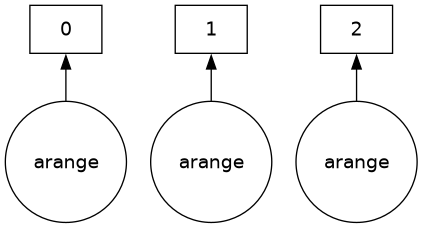

In [37]:
import numpy as np
import dask.array as da

x = da.arange(0, 15, chunks=(5,)) # puntos distribuidos equitativamente

dict(x.__dask_graph__())
# {('arange-539766a', 0): (np.arange, 0, 5),
#  ('arange-539766a', 1): (np.arange, 5, 10),
#  ('arange-539766a', 2): (np.arange, 10, 15)}

x.visualize(filename=None)

### Claves del grafo de tareas (task graph)

Por convención, cada **bloque** de un Dask array se representa mediante una **tupla** de la forma `(nombre, i, j, k)`, donde `i`, `j`, `k` son los índices del bloque en cada dimensión, comenzando desde 0 hasta la cantidad total de bloques en esa dimensión.

Cada **grafo de tareas** es un diccionario que contiene pares clave-valor que asocian estas claves con las operaciones necesarias para construir cada bloque. Además, puede contener otras claves y operaciones auxiliares necesarias para calcular los valores deseados.

Ejemplo ilustrativo de un grafo (plano, aunque normalmente se organiza como un `HighLevelGraph`):

```python
{
  ('arange-539766a', 0): (np.arange, 0, 5),
  ('arange-539766a', 1): (np.arange, 5, 10),
  ('arange-539766a', 2): (np.arange, 10, 15)
}


In [1]:
import dask.array as da

dask_example = da.random.random((3_000, 3_000), chunks=(1_000, 1_000))
dask_example

dask.array<random_sample, shape=(3000, 3000), dtype=float64, chunksize=(1000, 1000), chunktype=numpy.ndarray>

In [2]:
c = (dask_example + dask_example.T)
c

dask.array<add, shape=(3000, 3000), dtype=float64, chunksize=(1000, 1000), chunktype=numpy.ndarray>

In [3]:
%%time
res_dask = c.compute()

CPU times: user 216 ms, sys: 840 ms, total: 1.06 s
Wall time: 359 ms


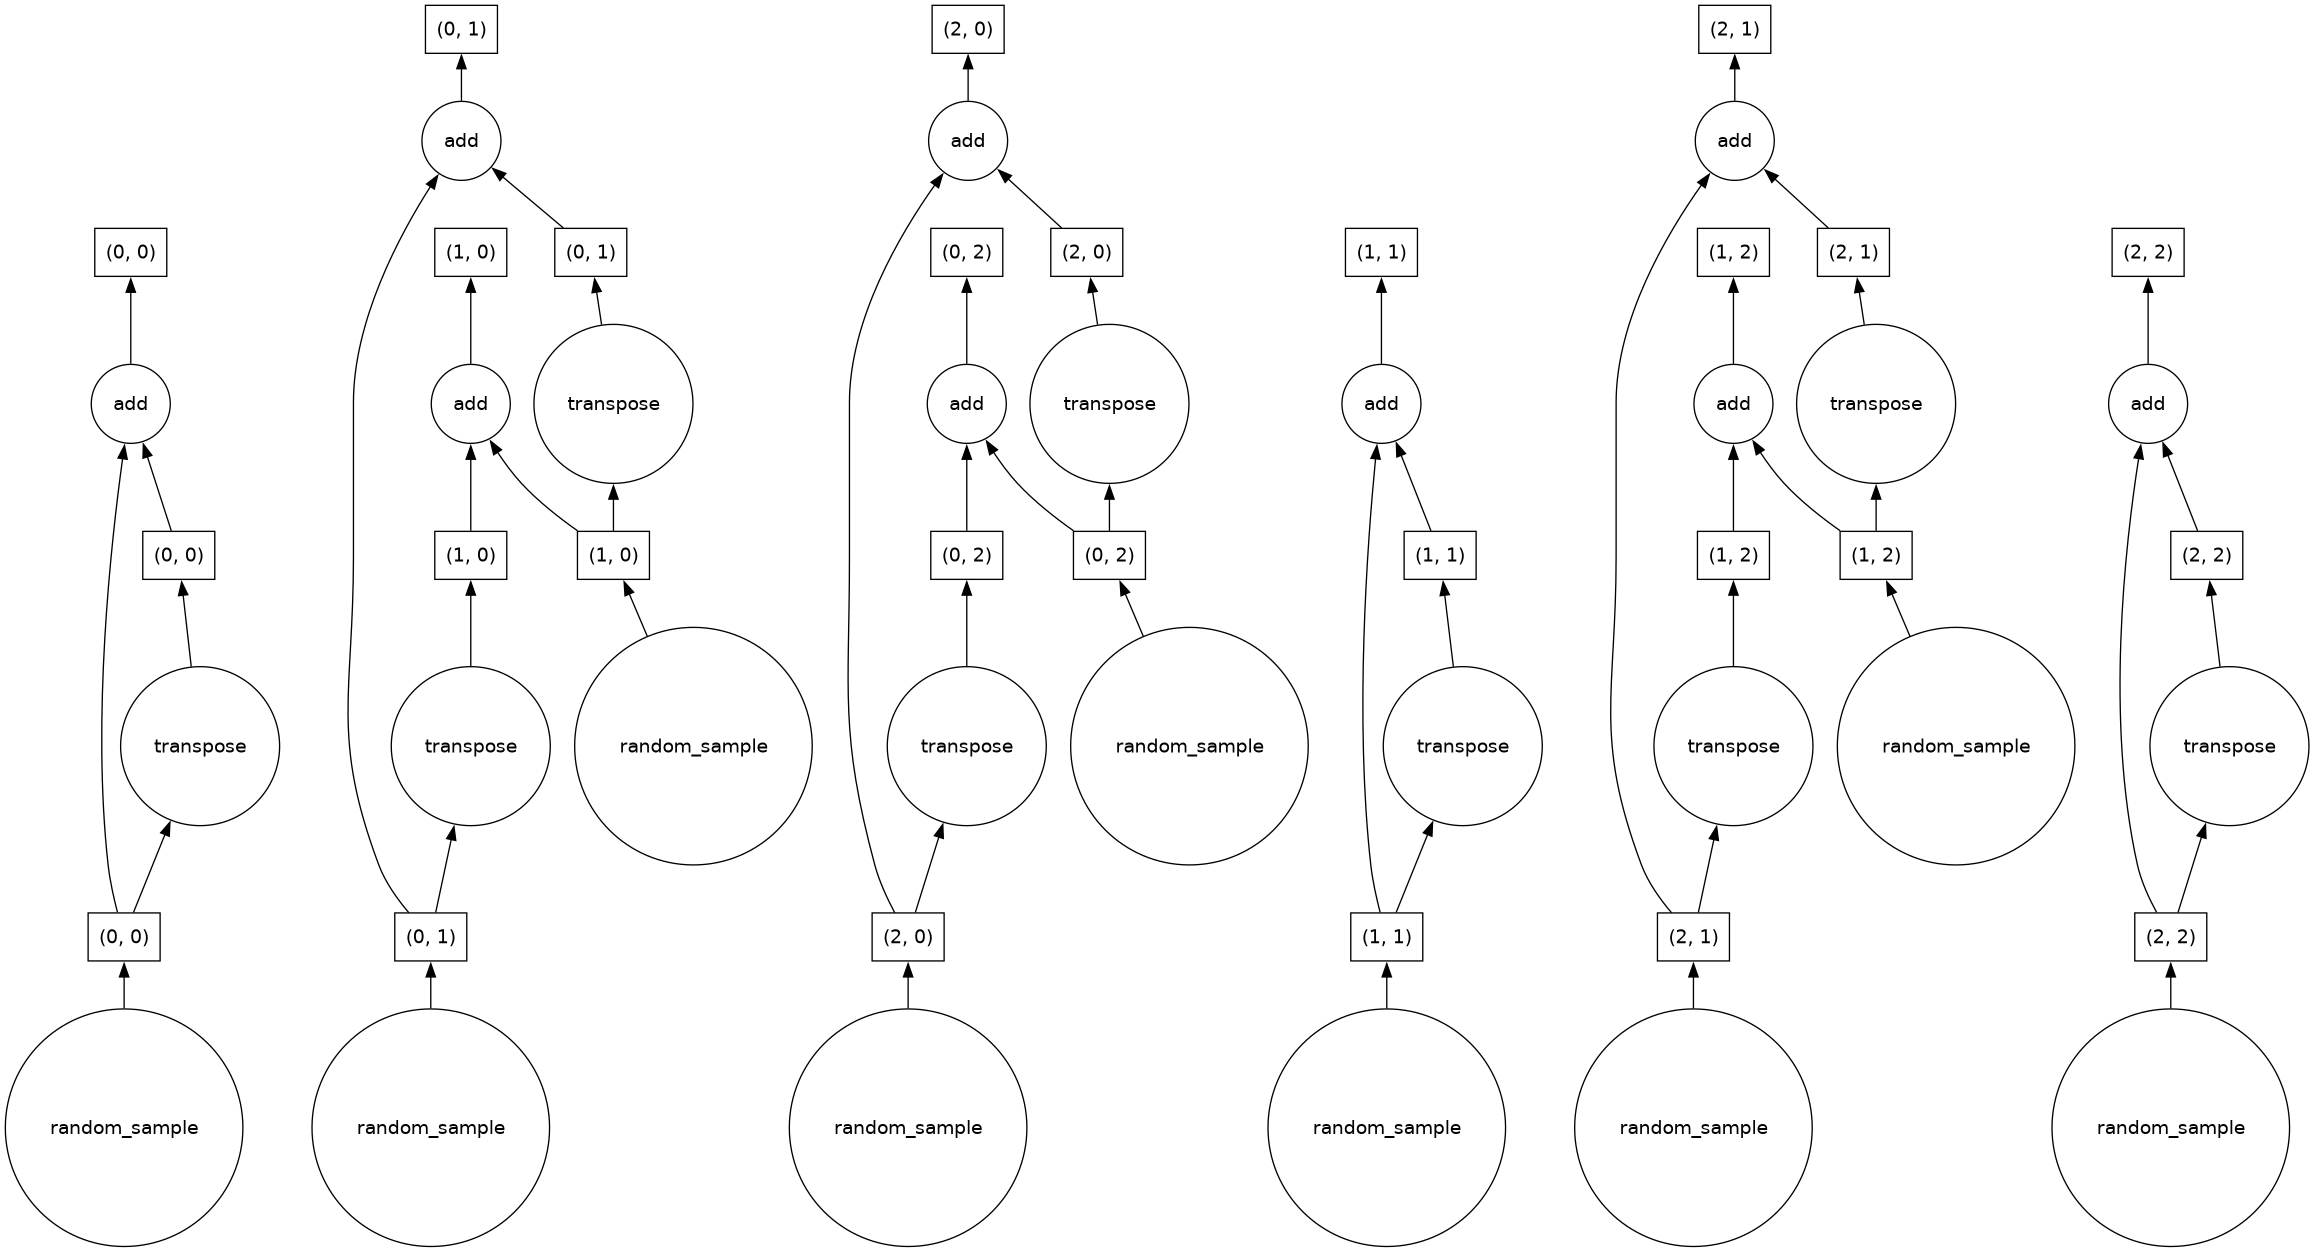

In [4]:
c.visualize()

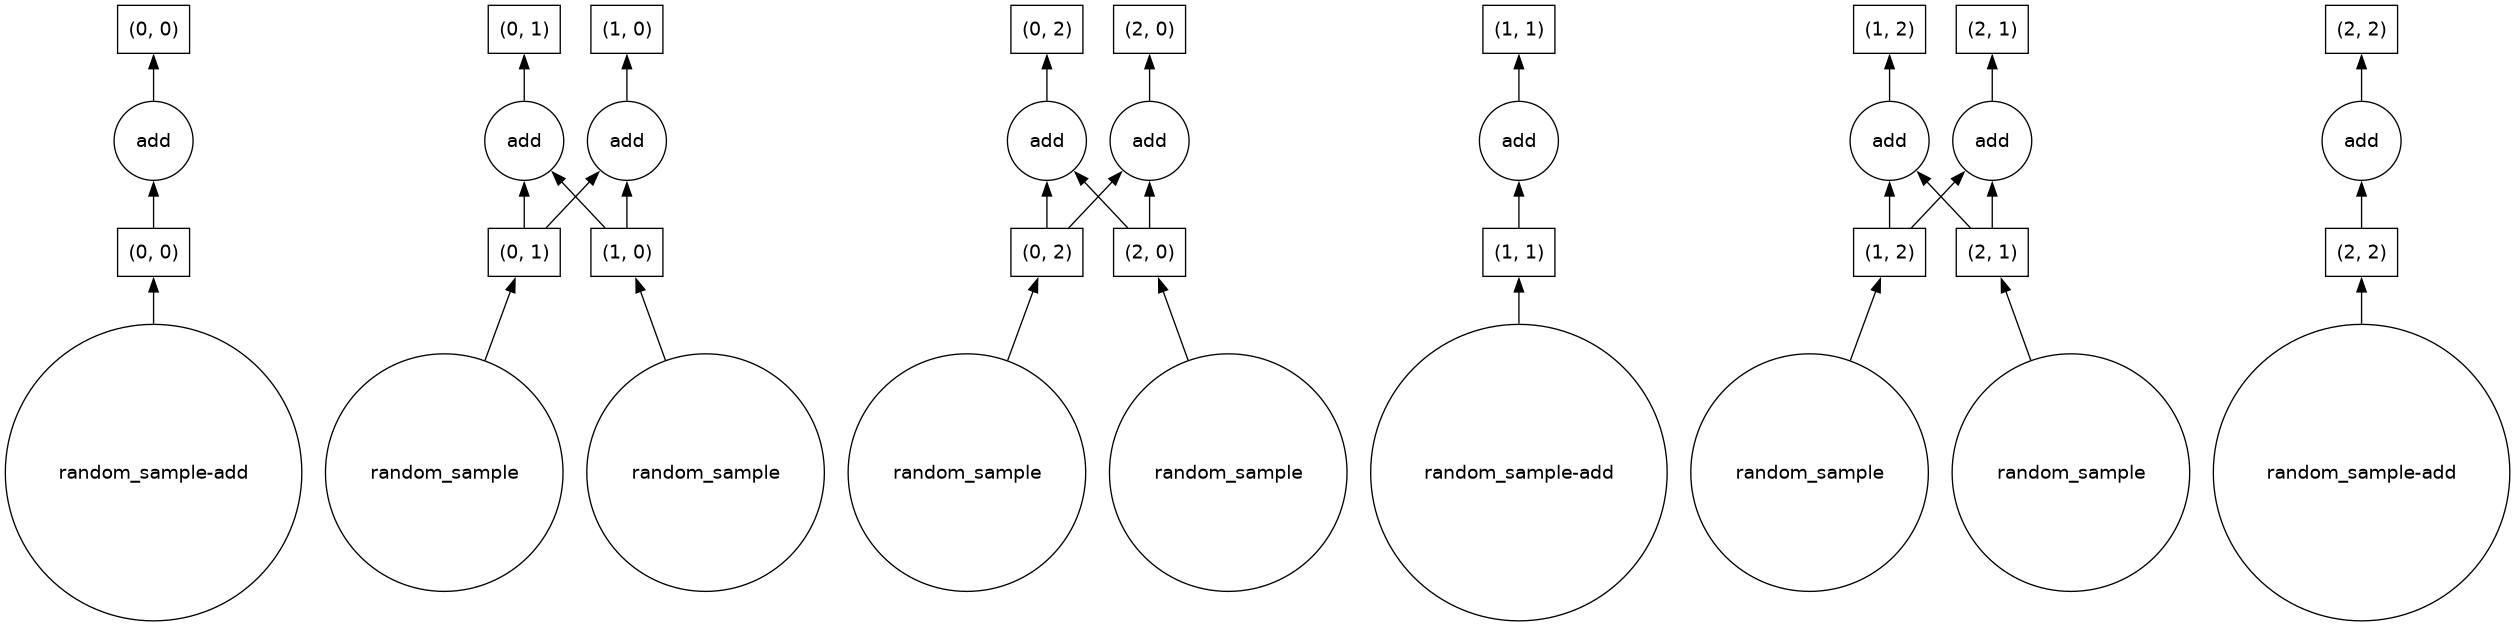

In [5]:
c.visualize(filename=None, optimize_graph=True)

## Diagnostics

In [6]:
from dask.distributed import LocalCluster
cluster = LocalCluster()
client = cluster.get_client()
client

/home/divasco/Documents/tads_rds/.venv/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 35535 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:35535/status,
Dashboard: http://127.0.0.1:35535/status,Workers: 4
Total threads: 12,Total memory: 15.41 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41449,Workers: 0
Dashboard: http://127.0.0.1:35535/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40447,Total threads: 3
Dashboard: http://127.0.0.1:39521/status,Memory: 3.85 GiB
Nanny: tcp://127.0.0.1:41553,


In [7]:
from dask.diagnostics import (Profiler, ResourceProfiler, 
                              visualize, ProgressBar)
ProgressBar().register()

In [8]:
import dask.array as da

dask_example = da.random.normal(size=(20_000, 20_000), chunks=(2_000, 2_000))

with Profiler() as prof, ResourceProfiler(dt=0.2) as rprof:
    dask_example[::50].mean(axis=0).compute()
visualize([prof, rprof], save=False);

## Task Graphs

Internamente, Dask codifica los algoritmos en un formato de grafo que puede utilizarse de forma aislada, sin necesidad de las colecciones de Dask.

Trabajar directamente con los grafos de tareas es poco común y deberia evitarse a menos que estemos desarrollando nuevos módulos con Dask.

![img](./images/sinopsis.gif)


## Dask como Especificacion

Dask representa algoritmos como **Grafos Dirigidos Acíclicos (DAGs)** de tareas con dependencias de datos, usando estructuras de datos estándar de Python: `dict`, `tuple`, funciones y valores arbitrarios.

Cada **grafo de tareas** o **task graph** es un diccionario que mapea claves a computo.

Una **claves** puede ser de tipo string, bytes, int, float, or tuple.

Y una **tarea** es una tupla con un *callable* como primer elemento y los elementos siguientes son los argumentos. Un argumento puede ser cualquier cálculo válido.

Un cálculo puede ser

- Cualquier clave presente en el grafo de Dask, como `'x'`
- Cualquier otro valor literal, como `1`
- Otra tarea, como `(inc, 'x')`
- Una lista de cálculos, como `[1, 'x', (inc, 'x')]`

Los siguientes son cálculos validos:

```python
np.array([...])
(add, 1, 2)
(add, 'x', 2)
(add, (inc, 'x'), 2)
(sum, [1, 2])
(sum, ['x', (inc, 'x')])
(np.dot, np.array([...]), np.array([...]))
[(sum, ['x', 'y']), 'z']
```




### Delayed

- Mas bajo nivel que los Dask Arrays y Dask DataFrames
- Permite "ordenar" el paralelismo de forma eficiente
- Construye el **task graph**

In [ ]:
def inc(x):
    return x + 1

def double(x):
    return x * 2

def add(x, y):
    return x + y

data = [1, 2, 3, 4, 5]

output = []
for x in data:
    a = inc(x)
    b = double(x)
    c = add(a, b)
    output.append(c)

total = sum(output)

In [12]:
from dask import delayed

@delayed
def inc(x):
    return x + 1

@delayed
def double(x):
    return x * 2

@delayed
def add(x, y):
    return x + y

data = [1, 2, 3, 4, 5]

output = []
for x in data:
    a = inc(x)
    b = double(x)
    c = add(a, b)
    output.append(c)

total = delayed(sum)(output)
total.compute()

50

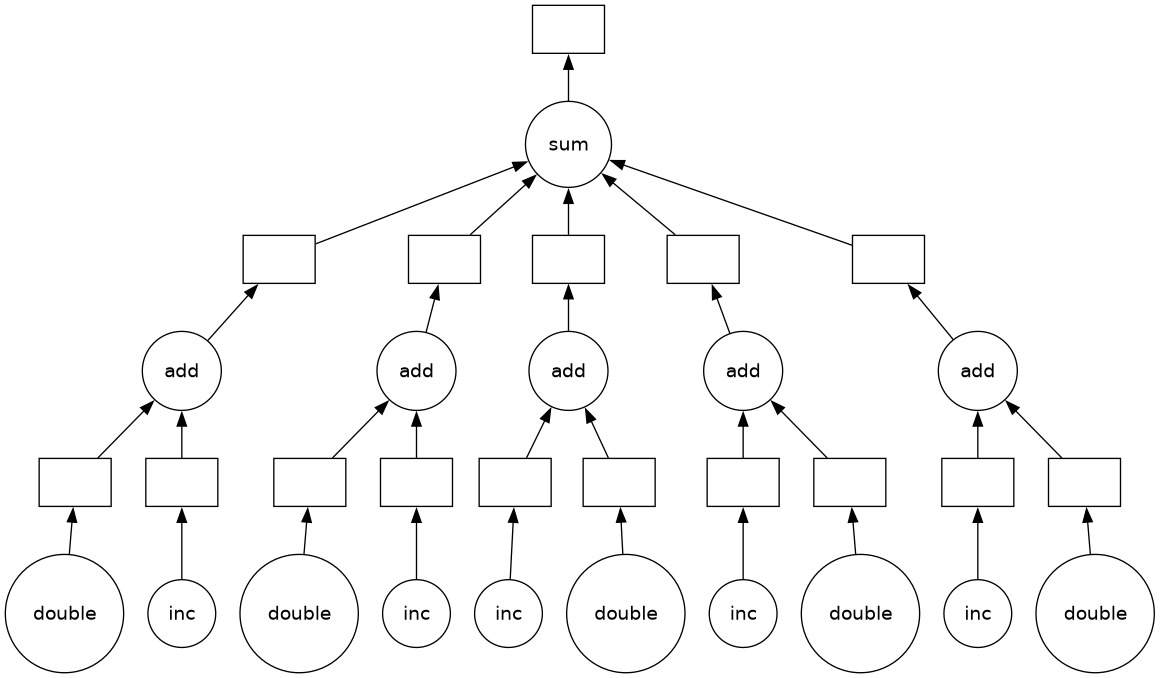

In [11]:
total.visualize(filename=None)

Si quisieramos hacer esto a mano seria algo como 

```python
{
    "x.0": 1,
    "a.0": (inc, 'x.0'),
    "b.0": (double, 'x.0'),
    "c.0": (add, 'a.0', 'b.0'),
    ...
    "x.4": 5,
    "a.4": (inc, 'x.4'),
    "b.4": (double, 'x.4'),
    "c.4": (add, 'a.4', 'b.4'),

    "sum": (sum, ['c.0', ..., 'c.4'])
}
```

Pero delayed nos da una interfaz piola

## Optimización

El módulo `dask.optimization` contiene varias funciones para transformar grafos de manera útil. 

**En la mayoría de los casos, los usuarios no necesitarán interactuar directamente con estas funciones.**

---

### Objetivos de la optimización de grafos

En general, hay dos objetivos al realizar optimizaciones de grafos:

1. **Simplificar los cálculos**
   
   - Se puede simplificar un grafo eliminando tareas innecesarias (función `cull`).

2. **Mejorar el paralelismo**
   
   - Se puede mejorar el paralelismo reduciendo la comunicación entre tareas, fusionando varias tareas en una sola (función `fuse`), o insertando operaciones baratas en línea (función `inline`, `inline_functions`).


### Ejemplo

In [1]:
def print_and_return(string):
    print(string)
    return string

def format_str(count, val, nwords):
    return (f'word list has {count} occurrences of '
            f'{val}, out of {nwords} words')

dsk = {'words': 'manzana naranja manzana pera naranja pera pera',
       'nwords': (len, (str.split, 'words')),
       'val1': 'naranja',
       'val2': 'manzana',
       'val3': 'pera',
       'count1': (str.count, 'words', 'val1'),
       'count2': (str.count, 'words', 'val2'),
       'count3': (str.count, 'words', 'val3'),
       'format1': (format_str, 'count1', 'val1', 'nwords'),
       'format2': (format_str, 'count2', 'val2', 'nwords'),
       'format3': (format_str, 'count3', 'val3', 'nwords'),
       'print1': (print_and_return, 'format1'),
       'print2': (print_and_return, 'format2'),
       'print3': (print_and_return, 'format3')}

Solamente contamos las ocurrencias de las palabras 'naranja', 'manzana' y 'pera' en la lista de palabras, formatteando el output que muestra los resultados, imprimiendolo y devolviendo el string del mismo.

![](./images/optimize_dask1.svg)

Para realizar el cálculo, primero eliminamos componentes innecesarios del grafo utilizando la función `cull` y luego pasamos el grafo y las claves de salida deseadas a una función `get` del planificador.

In [11]:
from dask.threaded import get
from dask.optimization import cull

outputs = ['print1', 'print2']
dsk1, dependencies = cull(dsk, outputs)  # remove unnecessary tasks from the graph

results = get(dsk1, outputs)
dsk1

{'print1': (<function __main__.print_and_return(string)>, 'format1'),
 'print2': (<function __main__.print_and_return(string)>, 'format2'),
 'format1': (<function __main__.format_str(count, val, nwords)>,
  'count1',
  'val1',
  'nwords'),
 'format2': (<function __main__.format_str(count, val, nwords)>,
  'count2',
  'val2',
  'nwords'),
 'count1': (<method 'count' of 'str' objects>, 'words', 'val1'),
 'val1': 'naranja',
 'nwords': (<function len(obj, /)>,
  (<method 'split' of 'str' objects>, 'words')),
 'count2': (<method 'count' of 'str' objects>, 'words', 'val2'),
 'val2': 'manzana',
 'words': 'manzana naranja manzana pera naranja pera pera'}

Como se puede ver arriba, el planificador solo calculó las salidas solicitadas (nunca se calculó `'print3'`) gracias a que llamamos a la función `dask.optimization.cull`, que elimina las tareas innecesarias del grafo.

El culling es parte del proceso de optimización por defecto de casi todas las colecciones. Se suele llamarlo relativamente temprano para reducir la cantidad de trabajo en pasos posteriores.


In [9]:
from dask.optimization import cull
outputs = ['print1', 'print2']
dsk1, dependencies = cull(dsk, outputs)
dsk1

{'print1': (<function __main__.print_and_return(string)>, 'format1'),
 'print2': (<function __main__.print_and_return(string)>, 'format2'),
 'format1': (<function __main__.format_str(count, val, nwords)>,
  'count1',
  'val1',
  'nwords'),
 'format2': (<function __main__.format_str(count, val, nwords)>,
  'count2',
  'val2',
  'nwords'),
 'count1': (<method 'count' of 'str' objects>, 'words', 'val1'),
 'val1': 'naranja',
 'nwords': (<function len(obj, /)>,
  (<method 'split' of 'str' objects>, 'words')),
 'count2': (<method 'count' of 'str' objects>, 'words', 'val2'),
 'val2': 'manzana',
 'words': 'manzana naranja manzana pera naranja pera pera'}

![](./images/optimize_dask2.svg)

Ahora hay múltiples accesos a constantes como `'val1'` o `'val2'` en el grafo de Dask. Estas pueden ser insertadas directamente en las tareas para mejorar la eficiencia utilizando la función `inline`. Por ejemplo:

In [10]:
from dask.optimization import inline
dsk2 = inline(dsk1, dependencies=dependencies)
results = get(dsk2, outputs)
dsk2

{'words': 'manzana naranja manzana pera naranja pera pera',
 'val1': 'naranja',
 'val2': 'manzana',
 'print1': (<function __main__.print_and_return(string)>, 'format1'),
 'print2': (<function __main__.print_and_return(string)>, 'format2'),
 'format1': (<function __main__.format_str(count, val, nwords)>,
  'count1',
  'naranja',
  'nwords'),
 'format2': (<function __main__.format_str(count, val, nwords)>,
  'count2',
  'manzana',
  'nwords'),
 'count1': (<method 'count' of 'str' objects>,
  'manzana naranja manzana pera naranja pera pera',
  'naranja'),
 'nwords': (<function len(obj, /)>,
  (<method 'split' of 'str' objects>,
   'manzana naranja manzana pera naranja pera pera')),
 'count2': (<method 'count' of 'str' objects>,
  'manzana naranja manzana pera naranja pera pera',
  'manzana')}

![](./images/optimize_dask3.svg)

Ahora tenemos dos conjuntos de cadenas de tareas casi lineales. El único vínculo entre ellos es la función de conteo de palabras. Para operaciones baratas como esta, el **costo de serialización** puede ser **mayor que el de la propia computación**, por lo que puede ser más rápido realizar la computación más de una vez en lugar de pasar los resultados a todos los nodos. Para realizar esta inserción de funciones, se puede utilizar la función `inline_functions`:

In [12]:
from dask.optimization import inline_functions
dsk3 = inline_functions(dsk2, outputs, [len, str.split],
                        dependencies=dependencies)
results = get(dsk3, outputs)
dsk3

{'words': 'manzana naranja manzana pera naranja pera pera',
 'val1': 'naranja',
 'val2': 'manzana',
 'print1': (<function __main__.print_and_return(string)>, 'format1'),
 'print2': (<function __main__.print_and_return(string)>, 'format2'),
 'format1': (<function __main__.format_str(count, val, nwords)>,
  'count1',
  'naranja',
  (<function len(obj, /)>,
   (<method 'split' of 'str' objects>,
    'manzana naranja manzana pera naranja pera pera'))),
 'format2': (<function __main__.format_str(count, val, nwords)>,
  'count2',
  'manzana',
  (<function len(obj, /)>,
   (<method 'split' of 'str' objects>,
    'manzana naranja manzana pera naranja pera pera'))),
 'count1': (<method 'count' of 'str' objects>,
  'manzana naranja manzana pera naranja pera pera',
  'naranja'),
 'count2': (<method 'count' of 'str' objects>,
  'manzana naranja manzana pera naranja pera pera',
  'manzana')}

![](./images/optimize_dask4.svg)

Ahora tenemos un conjunto de tareas puramente lineales. Nos gustaría que el scheduler ejecute todas estas en el mismo worker para reducir la serialización de datos entre workers. Una opción es simplemente fusionar estas cadenas lineales en una única tarea grande utilizando la función `fuse`:

In [13]:
from dask.optimization import fuse
dsk4, dependencies = fuse(dsk3)
results = get(dsk4, outputs)
dsk4

{'words': 'manzana naranja manzana pera naranja pera pera',
 'val1': 'naranja',
 'val2': 'manzana',
 'print1': 'count1-format1-print1',
 'print2': 'count2-format2-print2',
 'count2-format2-print2': (<function __main__.print_and_return(string)>,
  (<function __main__.format_str(count, val, nwords)>,
   (<method 'count' of 'str' objects>,
    'manzana naranja manzana pera naranja pera pera',
    'manzana'),
   'manzana',
   (<function len(obj, /)>,
    (<method 'split' of 'str' objects>,
     'manzana naranja manzana pera naranja pera pera')))),
 'count1-format1-print1': (<function __main__.print_and_return(string)>,
  (<function __main__.format_str(count, val, nwords)>,
   (<method 'count' of 'str' objects>,
    'manzana naranja manzana pera naranja pera pera',
    'naranja'),
   'naranja',
   (<function len(obj, /)>,
    (<method 'split' of 'str' objects>,
     'manzana naranja manzana pera naranja pera pera'))))}

![](./images/optimize_dask5.svg)

Uniendo todo queda asi:

In [14]:
def optimize_and_get(dsk, keys):
    dsk1, deps = cull(dsk, keys)
    dsk2 = inline(dsk1, dependencies=deps)
    dsk3 = inline_functions(dsk2, keys, [len, str.split],
                            dependencies=deps)
    dsk4, deps = fuse(dsk3)
    return get(dsk4, keys)

optimize_and_get(dsk, outputs)

('word list has 2 occurrences of naranja, out of 7 words',
 'word list has 2 occurrences of manzana, out of 7 words')

En resumen, las operaciones anteriores logran lo siguiente:

- Se eliminaron las tareas innecesarias para la salida deseada utilizando `cull`
- Se insertaron constantes directamente en las tareas usando `inline`
- Se insertaron cálculos baratos con `inline_functions`, mejorando el paralelismo
- Se fusionaron tareas lineales para que se ejecuten en el mismo worker utilizando `fuse`

Como se mencionó anteriormente, **estas optimizaciones ya se realizan automáticamente en las colecciones de Dask**.

O sea: **NO las usen** (a noser que trabajes con grafos o cálculos personalizados)


## Schedulers

![](./images/dask-overview-schedulers.svg)

### Una sola maquina

Optimizados para uso local, ligeros, no requieren configuracion

- Threads
- Processes
- Synchronous

### Distributed

- Local: Una sola maquina
- Cluster: En una red

## Threads

- Multi-threading
- Recordemos que Python hace uso de un GIL, asi que es util para código no-Python (NumPy, Pandas)
- Memoria compartida
- Dask Arrays, Dask DataFrames, Delayed

## Processes

- Multi-processing
- Evita el GIL al usar multiples instancias del interprete
- No tienen memoria compartida, overhead de pasaje de datos
- Daks Bags

## Synchronous

- Single-threaded
- Principalmente util para logging y debugging
- Integracion con IPython

## Distributed

- Asincrono y dirigido por eventos
- Multiples flujos de computo de multiples clientes
- Dashboard
- Mejor manejo de datos intermedios que processes
- Dask Futures, Actors
